# Quickstart

This workflow is for a user who wants to use a basic linear model without tuning and would like to generate and plot uncertainty bounds for a weather forecast of a specific city.

Training Linear Baseline Model...
Fetching 14-day live forecast for Munich...
Computing uncertainty bounds...


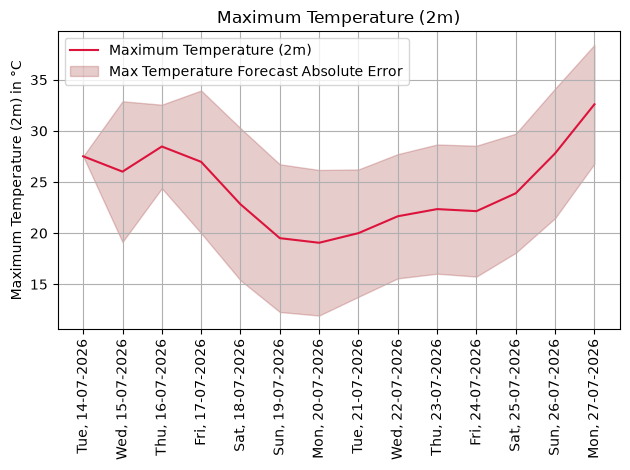

In [1]:
from fue.config import Config
from fue.data import Data
from fue.forecast import Forecast
from fue.models import LinearUncertaintyModel

# 1. Initialize Configuration and Data
# We use the default settings from config.json
config = Config()
data = Data()

# Read the historical raw dataset from disk to train a quick baseline model
data.read_raw()
dataset = data.generate_dataset()

# Split the data into train and validation sets (using the geographic quarantine)
train_df, val_df = data.split_dataset(dataset, val_fraction=0.2)

# Extract the configured feature and target column names
features = config.default_feature_columns
targets = config.default_target_columns

# 2. Train a Baseline Linear Model
print("Training Linear Baseline Model...")
linear_model = LinearUncertaintyModel(config=config)
linear_model.fit(train_df, features, targets)

# 3. Generate a Live Forecast
print("Fetching 14-day live forecast for Munich...")
forecaster = Forecast()

# Fetch live data (0 past days means we only want the future)
forecaster.fetch_forecast(location_name="munich", forecast_days=14, past_days=0)

# 4. Predict Uncertainty and Visualize
print("Computing uncertainty bounds...")
forecaster.compute_uncertainties(linear_model)

# Plot the predicted maximum temperature with its calculated error margin
forecaster.plot(target_variables="abs_diff__temperature_2m_max")